# Netflix Churn Analysis

### Importing Libraries and Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/SRJ/Desktop/Projects/Python/Python Project/netflix_customer_churn.csv")

In [3]:
df.shape

(5000, 14)

In [4]:
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,15,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,1,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,5,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,2,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [5]:
df.tail()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
4995,44f3ba44-b95d-4e50-a786-bac4d06f4a43,19,Female,Basic,49,11,Europe,Desktop,8.99,0,Credit Card,4,4.10,Drama
4996,18779bcb-ba2b-41da-b751-e70b812061ec,67,Female,Basic,9,2,North America,Desktop,8.99,0,PayPal,3,3.08,Documentary
4997,3f32e8c5-615b-4a3b-a864-db2688f7834f,66,Male,Standard,17,49,South America,Desktop,13.99,1,Debit Card,2,0.33,Action
4998,7b0ad82d-6571-430e-90f4-906259e0e89c,59,Female,Basic,9,3,Europe,Laptop,8.99,0,Credit Card,4,2.28,Sci-Fi
4999,82aeef39-ddb0-40ad-bae1-5c436e0cf042,57,Male,Basic,2,17,Africa,Mobile,8.99,1,Crypto,2,0.09,Action


### Data Cleaning

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   int64  
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(2), int64(5), object(7)
memor

In [7]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

In [9]:
df["customer_id"].duplicated().sum()

0

In [10]:
df.describe() # statistical values of the dataset

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649800,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.021567,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.000000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.000000,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.000000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.000000,60.000000,17.990000,1.000000,5.000000,98.420000


In [11]:
## Conversion of the values
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"

df["churned"] = df["churned"].apply(conv)

In [185]:
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,15,29,Africa,TV,8.99,yes,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,1,19,Europe,Mobile,13.99,yes,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16,10,Asia,TV,13.99,no,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,5,12,Oceania,TV,17.99,yes,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,2,13,Africa,Mobile,13.99,yes,Crypto,2,0.13,Action


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   int64  
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   object 
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(2), int64(4), object(8)
memor

### Data Visualisation

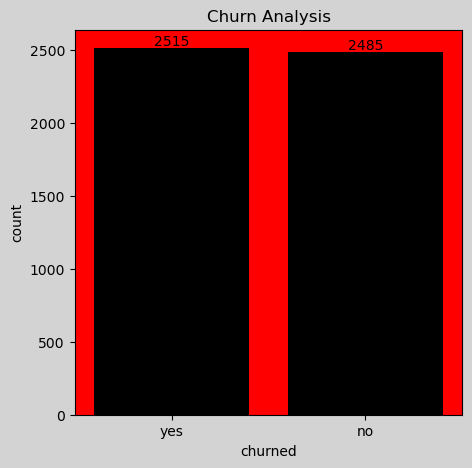

In [196]:
plt.figure(facecolor = "lightgrey", figsize = (5,5))
x = sns.countplot(x = "churned", data = df, color = "black")
x.set_facecolor("red")
x.bar_label(x.containers[0])
plt.title("Churn Analysis")
plt.show()

#### 2515 number of people have discountinued and 2485 number of people are continueing their membership

In [164]:
y = df["churned"].value_counts()

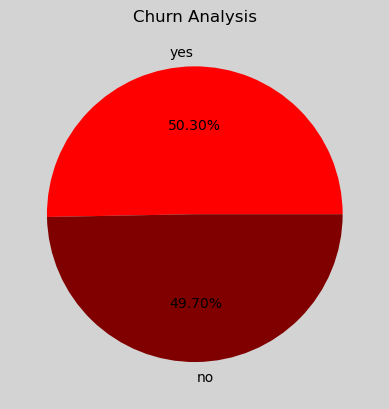

In [192]:
plt.figure(facecolor = "lightgrey")
ax = plt.gca()
ax.set_facecolor("white")
plt.pie(y,labels = y.index ,autopct = "%1.2f%%",colors = ["red", "maroon"])
plt.title("Churn Analysis")
plt.show()

#### 50.30 % discontinued and 49.70 % are continueing 

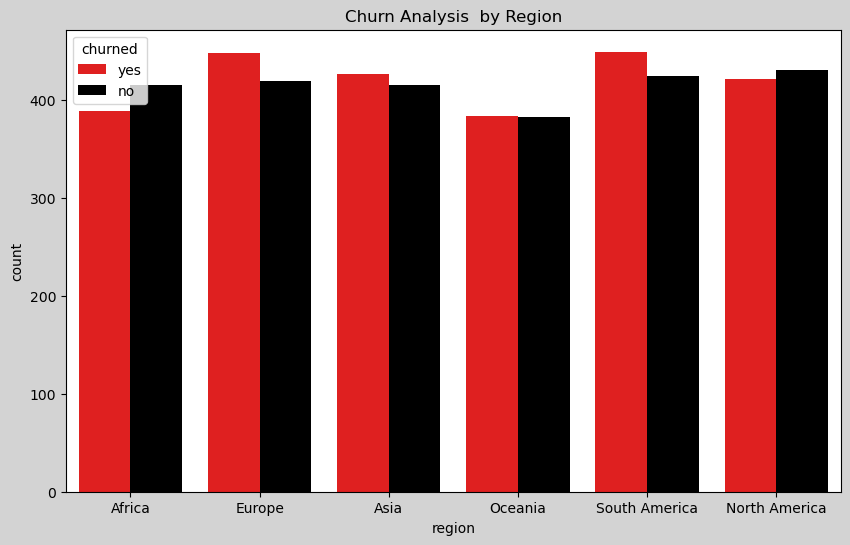

In [197]:
plt.figure(figsize =(10,6),facecolor = "lightgrey")
sns.countplot(x = df["region"], data =df, hue = "churned",palette = ["red","black"])
plt.title("Churn Analysis  by Region")
plt.show()

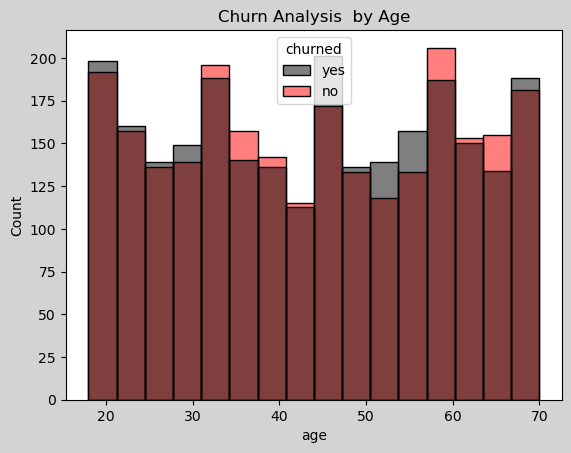

In [198]:
plt.figure(facecolor = "lightgrey")
sns.histplot(x = df["age"], data = df, hue = "churned" ,palette = ["black","red"])
plt.title("Churn Analysis  by Age")
plt.show()

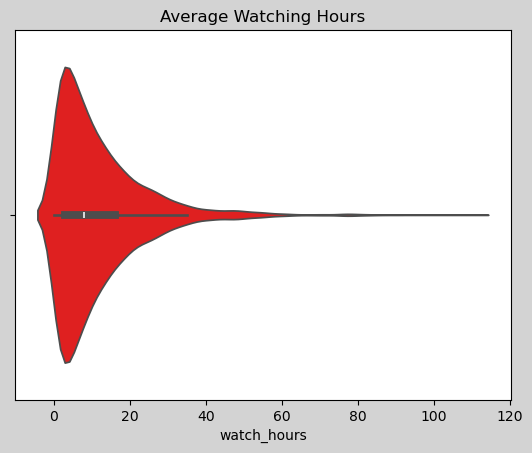

In [199]:
plt.figure(facecolor = "lightgrey")
sns.violinplot(x = df["watch_hours"],color = "red")
plt.title("Average Watching Hours")
plt.show()

In [156]:
df.columns

Index(['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours',
       'last_login_days', 'region', 'device', 'monthly_fee', 'churned',
       'payment_method', 'number_of_profiles', 'avg_watch_time_per_day',
       'favorite_genre'],
      dtype='object')

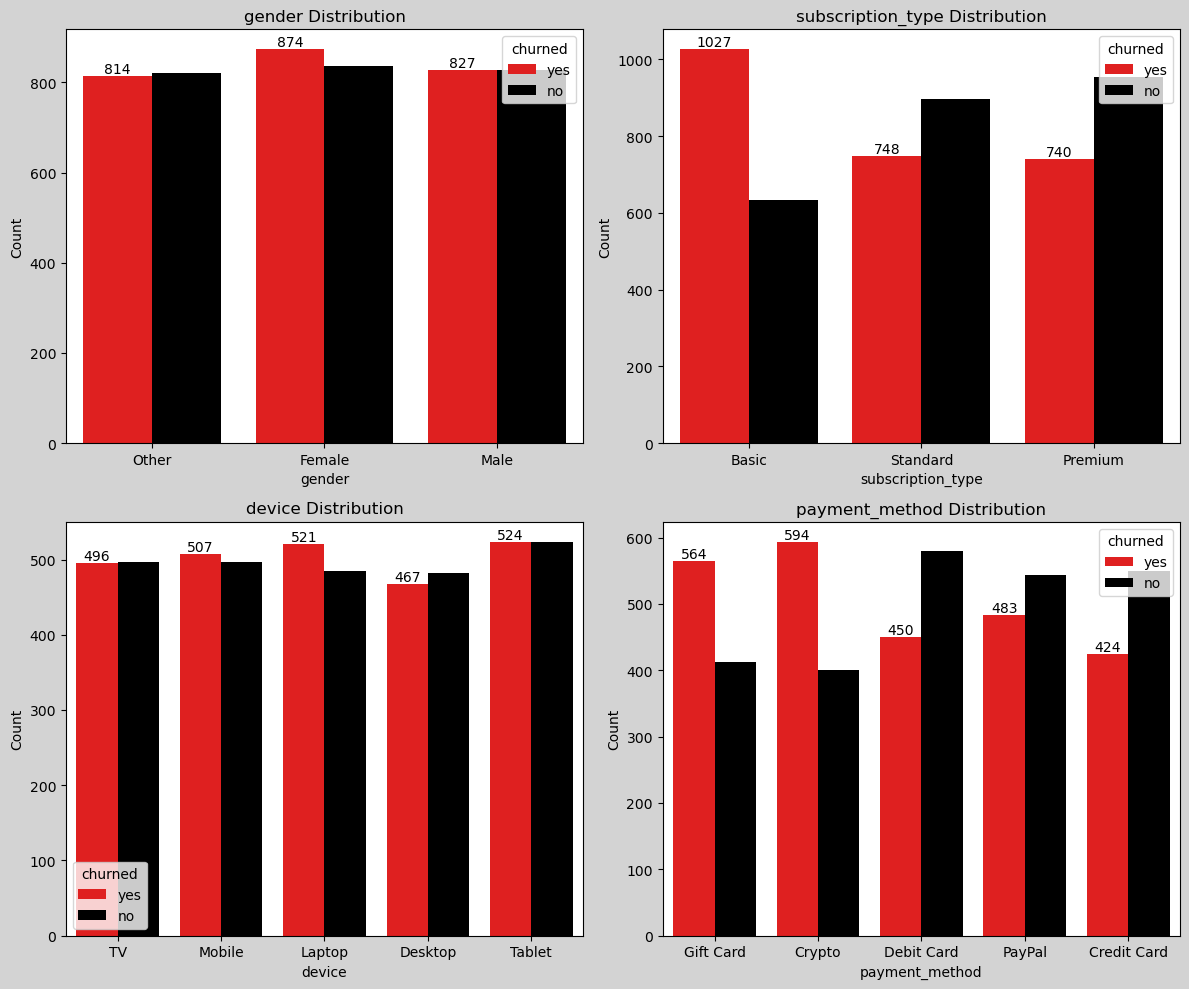

In [181]:
cols = ['gender', 'subscription_type', 'device', 'payment_method']

plt.figure(facecolor = "lightgrey",figsize=(12, 10))  # Size of the full figure

for i, col in enumerate(cols):
    plt.subplot(2, 2, i + 1)  # Create a 2x2 grid of plots
    z = sns.countplot(x=col, data=df,hue = "churned", palette=['red','black'])
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    z.bar_label(z.containers[0])

plt.tight_layout()
plt.show()


## 📊 Executive Summary: Netflix Customer Churn Analysis
### Objective:
The primary goal of this analysis was to investigate customer churn patterns within Netflix’s user base and identify potential trends and insights that can guide strategic decisions to reduce churn and improve customer retention.

### ✅ Data Cleaning & Preparation:
The dataset was loaded successfully and inspected using .head(), .info(), and .describe().

Null values and duplicates were checked and cleaned.

The churned column was converted from binary (0/1) to categorical ("no"/"yes") for easier interpretation.

### 📉 Key Insights from Visualizations:
#### 1. Churn Distribution:

📦 2515 customers discontinued their Netflix membership.

👥 2485 customers continued with the service.

📊 This shows a near 50-50 churn ratio:

50.30% churned

49.70% retained

#### 2. Visualization Tools Used:

Bar chart to depict churn counts using Seaborn.

Pie chart with custom colors (red/maroon) to visually represent the churn percentage.

#### 3. Styling and Presentation:

Charts were customized with background colors and face colors.

Each bar in the bar chart was annotated with values for clarity.

A clear and engaging visual representation was ensured using Matplotlib and Seaborn enhancements.

### 📌 Strengths of the Analysis:
Clean and well-prepared dataset.

Clear and visually appealing charts.

Insightful summary metrics (counts and percentages).

Coding structure is modular and readable, using helper functions where needed (e.g., for label conversion).

